✅ Notes for this setup

- No feature scaling → XGBoost doesn’t need it.

- No need to drop multicollinear features → trees handle it naturally.

- Default hyperparameters already give strong performance.

Later you can:

- Tune max_depth, learning_rate, n_estimators.

- Use early_stopping_rounds with a validation set.

- Check feature importance with xgb.feature_importances_.

In [ ]:
# ================================================
# 1. Imports
# ================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ================================================
# 2. Load datasets (feature engineered, leakage-safe)
# ================================================
train_df = pd.read_csv("C:\\Users\\soaha\\Desktop\\ML-Projects\\House_price_prediction_endToEnd\\data\\processed\\feature_engineered_train.csv")
eval_df = pd.read_csv("C:\\Users\\soaha\\Desktop\\ML-Projects\\House_price_prediction_endToEnd\\data\\processed\\feature_engineered_eval.csv")
# ================================================
# 3. Define target & features
# ================================================
target = "price"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_eval = eval_df.drop(columns=[target])
y_eval = eval_df[target]

print("Train shape:", X_train.shape)
print("Eval shape:", X_eval.shape)

# ================================================
# 4. Train a simple XGBoost Regressor
# ================================================
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ================================================
# 5. Evaluate performance
# ================================================
y_pred = xgb_model.predict(X_eval)

mae = mean_absolute_error(y_eval, y_pred)
rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)



print("XGBoost Performance:")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: {r2:.4f}")


Train shape: (576853, 37)
Eval shape: (148448, 37)
XGBoost Performance:
MAE: $35,626.41
RMSE: $72,674.67
R²: 0.9592


In [2]:
X_train.columns

Index(['year', 'quarter', 'month', 'median_list_price', 'median_ppsf',
       'median_list_ppsf', 'homes_sold', 'pending_sales', 'new_listings',
       'inventory', 'median_dom', 'avg_sale_to_list', 'sold_above_list',
       'off_market_in_two_weeks', 'bank', 'bus', 'hospital', 'mall', 'park',
       'restaurant', 'school', 'station', 'supermarket', 'Total Population',
       'Median Age', 'Per Capita Income', 'Total Families Below Poverty',
       'Total Housing Units', 'Median Rent', 'Total Labor Force',
       'Unemployed Population', 'Total School Age Population',
       'Median Commute Time', 'lat', 'lng', 'zipcode_freq', 'city_encoded'],
      dtype='object')

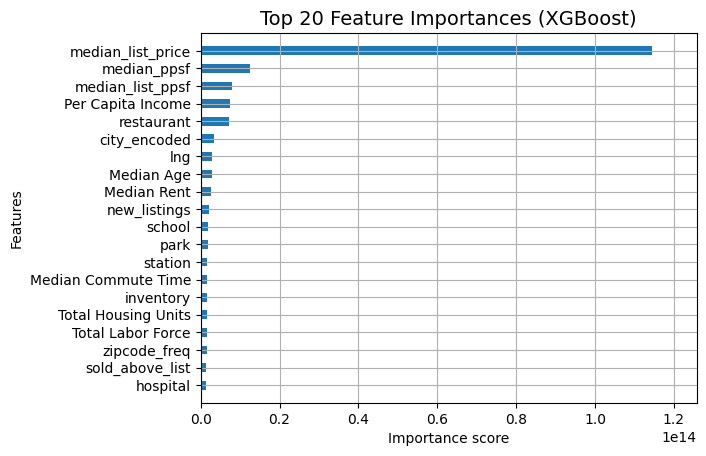

In [3]:
# Plot importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False
)
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.show()

We can see that there seems to be data leakage in median_list_price,median_ppsf and median_list_ppsf. Our goal is to understand the major features which contribute to house prices which don't correlate to the target 'price' at all, which would make our model more robust. So, we will drop the median columns.

In [ ]:
# ================================================
# 1. Imports
# ================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# ================================================
# 2. Load datasets (feature engineered, leakage-safe)
# ================================================
train_df = pd.read_csv("C:\\Users\\soaha\\Desktop\\ML-Projects\\House_price_prediction_endToEnd\\data\\processed\\feature_engineered_train.csv")
eval_df = pd.read_csv("C:\\Users\\soaha\\Desktop\\ML-Projects\\House_price_prediction_endToEnd\\data\\processed\\feature_engineered_eval.csv")

train_df = pd.read_csv(train_path)
eval_df = pd.read_csv(eval_path)

# ================================================
# 3. Define target & features (DROPPING LEAKAGE COLUMNS)
# ================================================
target = "price"

# We drop median_list_price and ppsf (price per sq ft) because they 
# are proxies for the target variable 'price'.
cols_to_drop = [target, "median_list_price", "median_ppsf", "median_list_ppsf"]

# Using errors='ignore' in case some of these aren't in both dataframes
X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
y_train = train_df[target]

X_eval = eval_df.drop(columns=cols_to_drop, errors='ignore')
y_eval = eval_df[target]

print(f"Dropped: {[c for c in cols_to_drop if c != target]}")
print("Train shape:", X_train.shape)
print("Eval shape:", X_eval.shape)

# ================================================
# 4. Train XGBoost Regressor
# ================================================
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ================================================
# 5. Evaluate performance
# ================================================
y_pred = xgb_model.predict(X_eval)

# Calculating standard metrics for the project
mae = mean_absolute_error(y_eval, y_pred)
rmse = np.sqrt(mean_squared_error(y_eval, y_pred))
r2 = r2_score(y_eval, y_pred)


print("\nXGBoost Performance (Leakage-Free):")
print("-" * 30)
print(f"MAE:   ${mae:,.2f}")
print(f"RMSE:  ${rmse:,.2f}")
print(f"R²:    {r2:.4f}")

Dropped: ['median_list_price', 'median_ppsf', 'median_list_ppsf']
Train shape: (576853, 34)
Eval shape: (148448, 34)

XGBoost Performance (Leakage-Free):
------------------------------
MAE:   $67,635.39
RMSE:  $123,962.58
R²:    0.8812


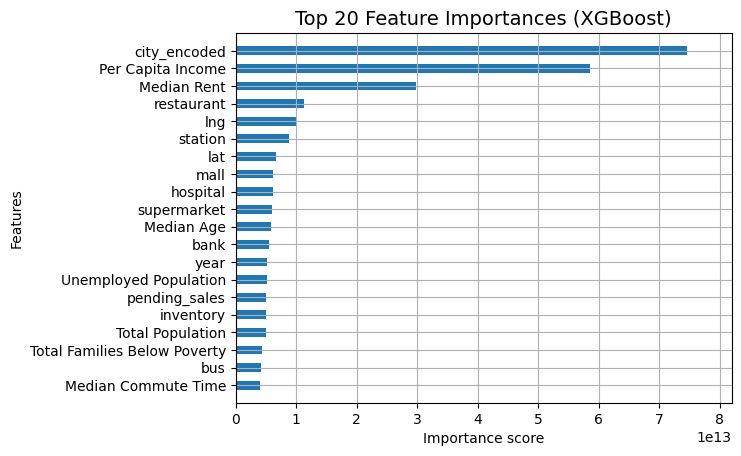

In [5]:
# Plot importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False
)
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.show()